# DPO from Scratch with Qwen2.5-0.5B

We will:
1. Load Qwen
2. Load preference data
3. Compute chosen/rejected log-probabilities
4. Compute the DPO loss
5. Train the policy
6. Check whether preference margin improves

In [1]:
!pip install -q -U "torchao>=0.16.0" "peft>=0.17.0" "transformers>=4.55.0" accelerate

In [2]:
import gc
import torch
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

from datasets import load_dataset
from peft import LoraConfig, get_peft_model

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

dtype = torch.float16 if device == "cuda" else torch.float32

# -------------------------
# Policy
# -------------------------

base_policy = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype
)

# -------------------------
# Reference
# -------------------------

reference = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype
)

# Disable KV cache during training
base_policy.config.use_cache = False

# Gradient checkpointing saves activation memory
base_policy.gradient_checkpointing_enable()

reference.eval()

for p in reference.parameters():
    p.requires_grad = False

print("Models loaded.")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Models loaded.


In [4]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    task_type="CAUSAL_LM"
)

policy = get_peft_model(
    base_policy,
    lora_config
)

policy.print_trainable_parameters()

trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184


In [5]:
policy = policy.to(device)

# Gradient checkpointing for lower VRAM
policy.config.use_cache = False
policy.base_model.gradient_checkpointing_enable()

reference = reference.to(device)
reference.eval()

for param in reference.parameters():
    param.requires_grad = False

print("Policy dtype:", next(policy.parameters()).dtype)
print("Reference dtype:", next(reference.parameters()).dtype)

print(
    "GPU memory:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB"
)

Policy dtype: torch.float16
Reference dtype: torch.float16
GPU memory: 1.86 GB


In [6]:
policy = policy.to(device)
reference = reference.to(device)

print(
    "GPU memory:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB"
)

GPU memory: 1.86 GB


In [7]:
dataset = load_dataset(
    "HuggingFaceH4/ultrafeedback_binarized",
    split="train_prefs"
)

print(dataset)

Dataset({
    features: ['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected'],
    num_rows: 61135
})


In [8]:
sample = dataset[0]

print("Prompt:")
print(sample["prompt"])

print("\nChosen:")
print(sample["chosen"])

print("\nRejected:")
print(sample["rejected"])

Prompt:
how can i develop a habit of drawing daily

Chosen:
[{'content': 'how can i develop a habit of drawing daily', 'role': 'user'}, {'content': "Developing a daily habit of drawing can be challenging but with consistent practice and a few tips, it can become an enjoyable and rewarding part of your daily routine. Here are some strategies to help you develop the habit of drawing daily:\n\n1. Set a specific time: Allocate a specific time of the day to draw. It could be in the morning, afternoon, or evening. Make drawing a part of your daily routine.\n2. Set a specific duration: Determine the amount of time you want to spend on drawing each day. It can be as little as 10 minutes or as long as an hour. Be consistent with the duration to help build the habit.\n3. Start small and simple: Don't try to create a masterpiece every day, start with simple and easy-to-do sketches. Focus on improving your skills gradually.\n4. Use a variety of tools and mediums: Experiment with different tools li

## 4. Sequence log-probability

For a response y:

log P(y|x)

is the sum of the log-probabilities of its response tokens.

We score only the assistant response, not the user prompt.

In [9]:
def get_sequence_logprob(
    model,
    prompt,
    conversation,
    max_length=512
):
    """
    Return log P(assistant response | prompt).

    Only assistant-response tokens contribute to the score.
    """

    # --------------------------------------------------
    # 1. Render the complete conversation
    # --------------------------------------------------

    full_text = tokenizer.apply_chat_template(
        conversation,
        tokenize=False,
        add_generation_prompt=False
    )

    # --------------------------------------------------
    # 2. Render prompt + assistant generation boundary
    # --------------------------------------------------

    prompt_messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    prompt_text = tokenizer.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # --------------------------------------------------
    # 3. Tokenize both
    # --------------------------------------------------

    full_tokens = tokenizer(
        full_text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    prompt_tokens = tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    input_ids = full_tokens["input_ids"].to(device)
    attention_mask = full_tokens["attention_mask"].to(device)

    prompt_length = prompt_tokens["input_ids"].shape[1]
    sequence_length = input_ids.shape[1]

    # If the entire sequence was truncated before the
    # assistant response begins, there is nothing to score.
    if prompt_length >= sequence_length:
        return torch.zeros(
            input_ids.shape[0],
            device=device,
            dtype=torch.float32
        )

    # --------------------------------------------------
    # 4. Forward pass
    # --------------------------------------------------

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    # --------------------------------------------------
    # 5. Next-token log probabilities
    # --------------------------------------------------

    logits = outputs.logits[:, :-1, :]
    labels = input_ids[:, 1:]

    log_probs = F.log_softmax(
        logits.float(),
        dim=-1
    )

    token_log_probs = torch.gather(
        log_probs,
        dim=-1,
        index=labels.unsqueeze(-1)
    ).squeeze(-1)

    # --------------------------------------------------
    # 6. Mask ONLY assistant response tokens
    # --------------------------------------------------

    response_mask = torch.zeros_like(
        token_log_probs,
        dtype=torch.bool
    )

    # token_log_probs index i corresponds to
    # input_ids token i+1
    response_start = prompt_length - 1

    response_mask[:, response_start:] = True

    # Also respect attention mask
    response_mask &= attention_mask[:, 1:].bool()

    # --------------------------------------------------
    # 7. Sum response token log-probs
    # --------------------------------------------------

    sequence_logprob = (
        token_log_probs * response_mask
    ).sum(dim=1)

    return sequence_logprob

In [10]:
# ==========================================
# DPO MARGIN CHECK
# ==========================================

sample = dataset[0]

prompt = sample["prompt"]
chosen = sample["chosen"]
rejected = sample["rejected"]

policy.eval()
reference.eval()

with torch.no_grad():

    chosen_policy = get_sequence_logprob(
        policy, prompt, chosen, max_length=512
    )

    rejected_policy = get_sequence_logprob(
        policy, prompt, rejected, max_length=512
    )

    chosen_ref = get_sequence_logprob(
        reference, prompt, chosen, max_length=512
    )

    rejected_ref = get_sequence_logprob(
        reference, prompt, rejected, max_length=512
    )

policy_margin = chosen_policy - rejected_policy

reference_margin = chosen_ref - rejected_ref

dpo_margin = (
    (chosen_policy - chosen_ref)
    - (rejected_policy - rejected_ref)
)

print("Chosen policy   :", chosen_policy.item())
print("Rejected policy :", rejected_policy.item())
print("Chosen ref      :", chosen_ref.item())
print("Rejected ref    :", rejected_ref.item())

print("\nPolicy margin   :", policy_margin.item())
print("Reference margin:", reference_margin.item())
print("DPO margin      :", dpo_margin.item())

Chosen policy   : -440.789794921875
Rejected policy : -243.12408447265625
Chosen ref      : -440.789794921875
Rejected ref    : -243.12408447265625

Policy margin   : -197.66571044921875
Reference margin: -197.66571044921875
DPO margin      : 0.0


## 5. Score one preference pair

We need four numbers:

policy(chosen)
policy(rejected)

reference(chosen)
reference(rejected)

In [12]:
sample = dataset[0]

prompt = sample["prompt"]
chosen = sample["chosen"]
rejected = sample["rejected"]

policy.train()

chosen_policy = get_sequence_logprob(
    policy,
    prompt,
    chosen
)

rejected_policy = get_sequence_logprob(
    policy,
    prompt,
    rejected
)

with torch.no_grad():

    chosen_reference = get_sequence_logprob(
        reference,
        prompt,
        chosen
    )

    rejected_reference = get_sequence_logprob(
        reference,
        prompt,
        rejected
    )

print("Chosen policy:   ", chosen_policy.item())
print("Rejected policy: ", rejected_policy.item())
print("Chosen reference:", chosen_reference.item())
print("Rejected reference:", rejected_reference.item())

Chosen policy:    -440.789794921875
Rejected policy:  -243.12408447265625
Chosen reference: -440.789794921875
Rejected reference: -243.12408447265625


## 6. DPO objective

DPO compares how much the policy favors the chosen answer
relative to the reference model.

Chosen advantage:

log πθ(chosen) - log πref(chosen)

Rejected advantage:

log πθ(rejected) - log πref(rejected)

DPO pushes the chosen advantage above the rejected advantage.

In [13]:
def dpo_loss(
    chosen_policy,
    rejected_policy,
    chosen_reference,
    rejected_reference,
    beta=0.1
):

    chosen_relative = (
        chosen_policy - chosen_reference
    )

    rejected_relative = (
        rejected_policy - rejected_reference
    )

    logits = beta * (
        chosen_relative - rejected_relative
    )

    loss = -F.logsigmoid(logits)

    return loss.mean()

In [14]:
loss = dpo_loss(
    chosen_policy,
    rejected_policy,
    chosen_reference,
    rejected_reference
)

print("DPO loss:", loss.item())

margin = (
    (chosen_policy - chosen_reference)
    -
    (rejected_policy - rejected_reference)
)

print("DPO margin:", margin.item())

DPO loss: 0.6931471824645996
DPO margin: 0.0


## 7. Train the policy

Only LoRA parameters receive gradients.
The reference model never changes.

In [15]:
from torch.optim import AdamW

optimizer = AdamW(
    policy.parameters(),
    lr=5e-5
)

In [16]:
optimizer.zero_grad()

loss.backward()

torch.nn.utils.clip_grad_norm_(
    policy.parameters(),
    max_norm=1.0
)

optimizer.step()

optimizer.zero_grad()

print("One DPO update completed.")

One DPO update completed.


## 8. Did the update move the policy?

We compare the policy's chosen-vs-rejected preference
before and after the update.

In [17]:
policy.eval()

with torch.no_grad():

    chosen_after = get_sequence_logprob(
        policy,
        prompt,
        chosen
    )

    rejected_after = get_sequence_logprob(
        policy,
        prompt,
        rejected
    )

margin_before = (
    chosen_policy - rejected_policy
).item()

margin_after = (
    chosen_after - rejected_after
).item()

print("Policy margin before:", margin_before)
print("Policy margin after: ", margin_after)

Policy margin before: -197.66571044921875
Policy margin after:  -190.58023071289062


## 9. Small DPO training loop

For each preference pair:

1. Score chosen/rejected with policy
2. Score chosen/rejected with reference
3. Calculate DPO loss
4. Backpropagate
5. Update LoRA parameters

In [18]:
from torch.utils.data import DataLoader

# -------------------------
# Training configuration
# -------------------------
train_subset = dataset.select(
    range(min(128, len(dataset)))
)
batch_size = 4
gradient_accumulation_steps = 4
beta = 0.1
max_length = 512
num_epochs = 1

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=lambda batch: batch
)

policy.train()

optimizer.zero_grad()

loss_history = []

optimizer_step = 0

for epoch in range(num_epochs):

    for batch_idx, batch in enumerate(train_loader):

        batch_losses = []

        # --------------------------------
        # Process every example in batch
        # --------------------------------

        for sample in batch:

            prompt = sample["prompt"]
            chosen = sample["chosen"]
            rejected = sample["rejected"]

            # Policy scores
            chosen_policy = get_sequence_logprob(
                policy,
                prompt,
                chosen,
                max_length=max_length
            )

            rejected_policy = get_sequence_logprob(
                policy,
                prompt,
                rejected,
                max_length=max_length
            )

            # Reference scores
            with torch.no_grad():

                chosen_reference = get_sequence_logprob(
                    reference,
                    prompt,
                    chosen,
                    max_length=max_length
                )

                rejected_reference = get_sequence_logprob(
                    reference,
                    prompt,
                    rejected,
                    max_length=max_length
                )

            # DPO loss for this example
            example_loss = dpo_loss(
                chosen_policy,
                rejected_policy,
                chosen_reference,
                rejected_reference,
                beta=beta
            )

            batch_losses.append(example_loss)

        # --------------------------------
        # Average loss across batch
        # --------------------------------

        batch_loss = torch.stack(batch_losses).mean()

        # Gradient accumulation
        loss = batch_loss / gradient_accumulation_steps

        loss.backward()

        # --------------------------------
        # Optimizer update
        # --------------------------------

        if (
            (batch_idx + 1) % gradient_accumulation_steps == 0
            or (batch_idx + 1) == len(train_loader)
        ):

            torch.nn.utils.clip_grad_norm_(
                policy.parameters(),
                max_norm=1.0
            )

            optimizer.step()
            optimizer.zero_grad()

            optimizer_step += 1

            loss_value = batch_loss.item()
            loss_history.append(loss_value)

            print(
                f"optimizer_step={optimizer_step:03d} "
                f"batch_loss={loss_value:.4f}"
            )

        # Cleanup
        del batch_losses
        del batch_loss

        gc.collect()

        if device == "cuda":
            torch.cuda.empty_cache()
            

optimizer_step=001 batch_loss=0.6910


OutOfMemoryError: CUDA out of memory. Tried to allocate 298.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 205.81 MiB is free. Process 10605 has 10.01 GiB memory in use. Including non-PyTorch memory, this process has 4.35 GiB memory in use. Of the allocated memory 3.98 GiB is allocated by PyTorch, and 233.78 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
# Save trained LoRA adapter
policy.save_pretrained("./dpo_lora")
tokenizer.save_pretrained("./dpo_lora")

print("LoRA adapter saved.")

LoRA adapter saved.


In [ ]:
del policy
gc.collect()
torch.cuda.empty_cache()

## 10. Preference evaluation

For each pair we check whether:

log π(chosen|x) > log π(rejected|x)

Higher preference accuracy means the policy agrees
with more of the human preference labels.

In [ ]:
from transformers import AutoModelForCausalLM
from peft import PeftModel

# Load fresh base model
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)

# Attach our trained LoRA adapter
policy = PeftModel.from_pretrained(
    base_model,
    "./dpo_lora"
).to(device)

policy.eval()

print("Trained DPO policy loaded.")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Trained DPO policy loaded.


In [ ]:
def preference_accuracy(
    model,
    eval_dataset,
    max_length=128,
    limit=50
):

    model.eval()

    correct = 0
    total = 0

    for sample in eval_dataset.select(
        range(min(limit, len(eval_dataset)))
    ):

        chosen_score = get_sequence_logprob(
            model,
            sample["prompt"],
            sample["chosen"],
            max_length=max_length
        )

        rejected_score = get_sequence_logprob(
            model,
            sample["prompt"],
            sample["rejected"],
            max_length=max_length
        )

        if chosen_score.item() > rejected_score.item():
            correct += 1

        total += 1

    return correct / total

In [ ]:
# ==========================================
# Evaluate the trained DPO policy
# ==========================================

policy.eval()

after_accuracy = preference_accuracy(
    policy,
    dataset,
    max_length=512,
    limit=50
)

print(f"Trained DPO policy accuracy: {after_accuracy:.2%}")

Trained DPO policy accuracy: 44.00%


## 11. Training diagnostics

We mainly watch:

- DPO loss
- preference accuracy
- chosen vs rejected margin
- NaN / Inf

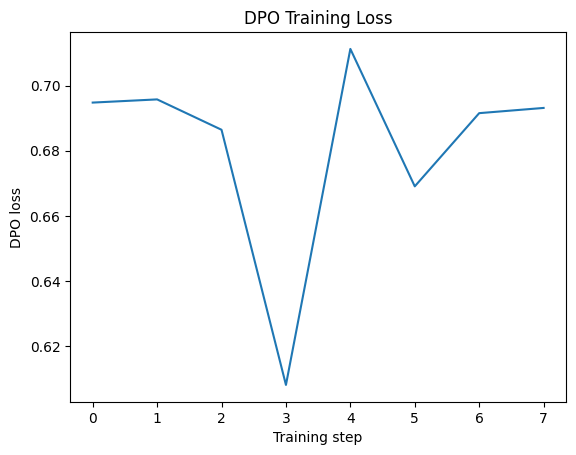

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_history)

plt.xlabel("Training step")
plt.ylabel("DPO loss")
plt.title("DPO Training Loss")

plt.show()

In [ ]:
print("Policy trainable parameters:")

trainable = sum(
    p.numel()
    for p in policy.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in policy.parameters()
)

print("Trainable:", trainable)
print("Total:", total)
print(
    "Trainable %:",
    100 * trainable / total
)

print(
    "Reference trainable:",
    any(
        p.requires_grad
        for p in reference.parameters()
    )
)

Policy trainable parameters:
Trainable: 1081344
Total: 495114112
Trainable %: 0.21840298504761665
Reference trainable: False


In [ ]:
# ==========================================
# CHECK CHAT FORMAT / RESPONSE MASKING
# ==========================================

sample = dataset[0]

prompt = sample["prompt"]
chosen = sample["chosen"]

print("PROMPT TYPE :", type(prompt))
print("CHOSEN TYPE :", type(chosen))

print("\nPROMPT:")
print(prompt)

print("\nCHOSEN:")
print(chosen)

# chosen is already a conversation
if isinstance(chosen, list):
    messages = chosen
else:
    messages = [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": chosen},
    ]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=False,
)

print("\nRENDERED CHAT:")
print(text)

tokens = tokenizer(
    text,
    return_tensors="pt"
)

print("\nTotal tokens:", tokens["input_ids"].shape[1])

PROMPT TYPE : <class 'str'>
CHOSEN TYPE : <class 'list'>

PROMPT:
how can i develop a habit of drawing daily

CHOSEN:
[{'content': 'how can i develop a habit of drawing daily', 'role': 'user'}, {'content': "Developing a daily habit of drawing can be challenging but with consistent practice and a few tips, it can become an enjoyable and rewarding part of your daily routine. Here are some strategies to help you develop the habit of drawing daily:\n\n1. Set a specific time: Allocate a specific time of the day to draw. It could be in the morning, afternoon, or evening. Make drawing a part of your daily routine.\n2. Set a specific duration: Determine the amount of time you want to spend on drawing each day. It can be as little as 10 minutes or as long as an hour. Be consistent with the duration to help build the habit.\n3. Start small and simple: Don't try to create a masterpiece every day, start with simple and easy-to-do sketches. Focus on improving your skills gradually.\n4. Use a variet